In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
np.random.seed(42)

days = 365
zones = 6

data = []

for day in range(days):
    for zone in range(1, zones+1):

        pm25 = np.random.randint(40,180)
        pm10 = np.random.randint(60,200)
        no2 = np.random.randint(10,80)
        co = np.random.uniform(0.5,3)

        temp = np.random.randint(20,40)
        wind = np.random.randint(2,15)
        rain = np.random.randint(0,20)

        traffic = np.random.randint(20,100)
        event = np.random.randint(0,2)

        aqi = (pm25*0.4 + pm10*0.3 + no2*0.2 + traffic*0.1)

        data.append([day,zone,pm25,pm10,no2,co,temp,wind,rain,traffic,event,aqi])

columns = ["Date","ZoneID","PM2.5","PM10","NO2","CO","Temperature","WindSpeed","Rainfall","Traffic","SpecialEvent","AQI"]

df = pd.DataFrame(data,columns=columns)

df.head()

,Date,ZoneID,PM2.5,PM10,NO2,CO,Temperature,WindSpeed,Rainfall,Traffic,SpecialEvent,AQI
0,0,1,142,152,24,2.329985,26,11,18,94,0,116.6
1,0,2,127,176,33,2.127221,21,9,11,49,1,115.1
2,0,3,169,80,42,1.260606,31,10,16,78,0,107.8
3,0,4,54,110,64,2.958077,22,6,18,26,0,70.0
4,0,5,112,77,13,2.855504,33,3,8,72,1,77.7


In [3]:
df.describe()

,Date,ZoneID,PM2.5,PM10,NO2,CO,Temperature,WindSpeed,Rainfall,Traffic,SpecialEvent,AQI
count,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000
mean,182.000000,3.500000,109.590868,128.758904,44.595434,1.742362,29.783105,7.954338,9.729680,59.539269,0.505023,97.337032
std,105.390093,1.708215,40.608491,40.425098,20.347861,0.726425,5.738554,3.721177,5.766349,23.024071,0.500089,20.678450
min,0.000000,1.000000,40.000000,60.000000,10.000000,0.501004,20.000000,2.000000,0.000000,20.000000,0.000000,44.800000
25%,91.000000,2.000000,75.000000,94.000000,26.000000,1.117057,25.000000,5.000000,5.000000,39.000000,0.000000,82.800000
50%,182.000000,3.500000,109.000000,129.000000,45.000000,1.752390,30.000000,8.000000,10.000000,60.000000,1.000000,97.500000
75%,273.000000,5.000000,145.000000,164.000000,63.000000,2.354256,35.000000,11.000000,15.000000,79.000000,1.000000,112.075000
max,364.000000,6.000000,179.000000,199.000000,79.000000,2.999294,39.000000,14.000000,19.000000,99.000000,1.000000,149.300000


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2190 entries, 0 to 2189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          2190 non-null   int64  
 1   ZoneID        2190 non-null   int64  
 2   PM2.5         2190 non-null   int64  
 3   PM10          2190 non-null   int64  
 4   NO2           2190 non-null   int64  
 5   CO            2190 non-null   float64
 6   Temperature   2190 non-null   int64  
 7   WindSpeed     2190 non-null   int64  
 8   Rainfall      2190 non-null   int64  
 9   Traffic       2190 non-null   int64  
 10  SpecialEvent  2190 non-null   int64  
 11  AQI           2190 non-null   float64
dtypes: float64(2), int64(10)
memory usage: 205.4 KB


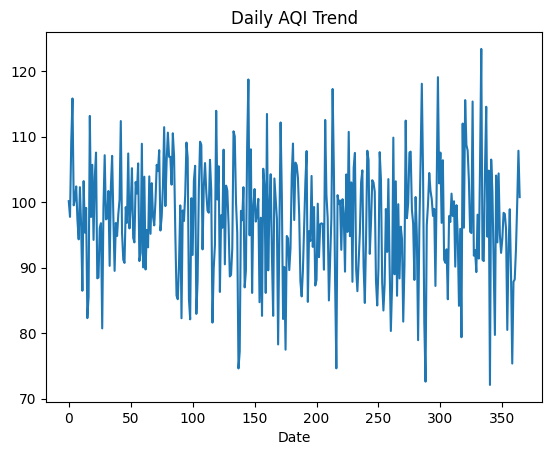

In [5]:
plt.figure()
df.groupby("Date")["AQI"].mean().plot()
plt.title("Daily AQI Trend")
plt.show()

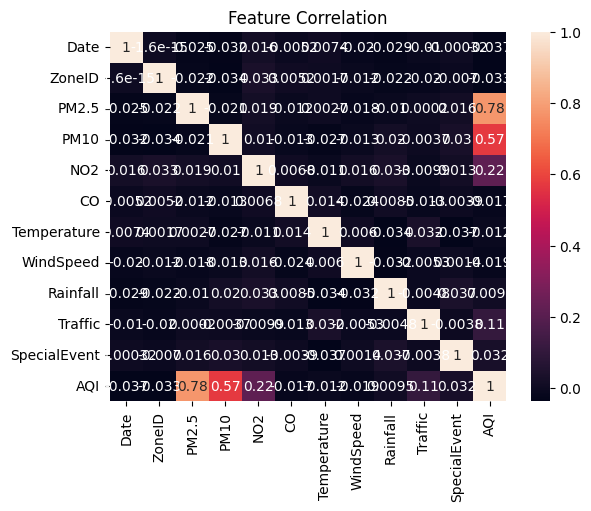

In [6]:
plt.figure()
sns.heatmap(df.corr(),annot=True)
plt.title("Feature Correlation")
plt.show()

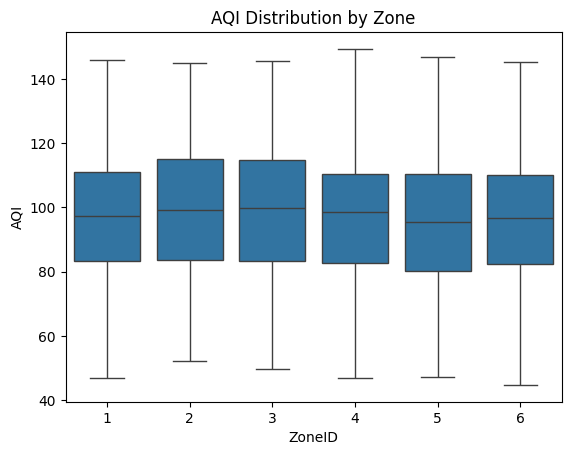

In [7]:
plt.figure()
sns.boxplot(x="ZoneID",y="AQI",data=df)
plt.title("AQI Distribution by Zone")
plt.show()

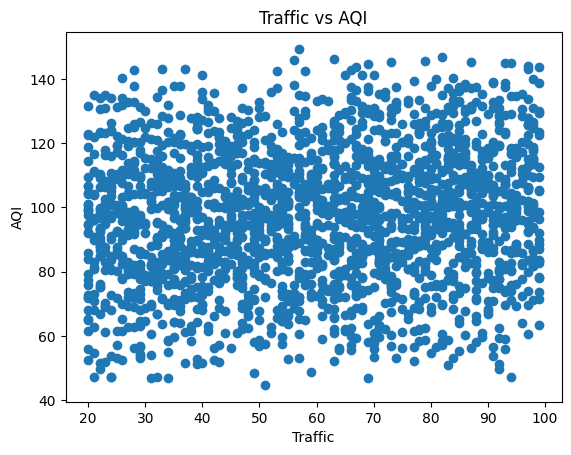

In [8]:
plt.figure()
plt.scatter(df["Traffic"],df["AQI"])
plt.xlabel("Traffic")
plt.ylabel("AQI")
plt.title("Traffic vs AQI")
plt.show()

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df[["PM2.5","PM10","NO2","Traffic","Temperature","WindSpeed","Rainfall"]]
y = df["AQI"]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

model = LinearRegression()

model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [10]:
pred = model.predict(X_test)

In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE:",mean_absolute_error(y_test,pred))

print("RMSE:",np.sqrt(mean_squared_error(y_test,pred)))

print("R2 Score:",r2_score(y_test,pred))

MAE: 1.0366137172390503e-14
RMSE: 1.4630497707157744e-14
R2 Score: 1.0


In [12]:
def aqi_category(aqi):

    if aqi <= 50:
        return "Good"

    elif aqi <= 100:
        return "Moderate"

    elif aqi <= 200:
        return "Unhealthy"

    else:
        return "Severe"

In [15]:
import pandas as pd

input_data = pd.DataFrame(
    [[pm25,pm10,no2,traffic,temp,wind,rain]],
    columns=["PM2.5","PM10","NO2","Traffic","Temperature","WindSpeed","Rainfall"]
)

prediction = model.predict(input_data)

In [16]:
print("Enter pollution details")

pm25 = float(input("PM2.5: "))
pm10 = float(input("PM10: "))
no2 = float(input("NO2: "))
traffic = float(input("Traffic Index: "))
temp = float(input("Temperature: "))
wind = float(input("Wind Speed: "))
rain = float(input("Rainfall: "))

prediction = model.predict([[pm25,pm10,no2,traffic,temp,wind,rain]])

aqi = prediction[0]

print("Predicted AQI:",aqi)

print("Air Quality:",aqi_category(aqi))

Enter pollution details


PM2.5:  120
PM10:  150
NO2:  40
Traffic Index:  70
Temperature:  32
Wind Speed:  8
Rainfall:  2


Predicted AQI: 108.0
Air Quality: Unhealthy


C:\Users\Asus\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
